# Key Exploratory Findings

## 1. Indicator Overview and Baseline

The **Minimum Dietary Diversity for Women (MDD-W)** is a population-level indicator used to assess dietary diversity among non-pregnant women aged 15–49 years. It measures whether a woman consumed foods from at least **5 out of 10 defined food groups** during the previous 24 hours. Achieving this threshold is associated with a higher likelihood of adequate micronutrient intake.

To prevent very small quantities of food from artificially improving dietary diversity scores, foods consumed in amounts below **15 grams (approximately one tablespoon)** are excluded from the assessment.

---

## 2. Global Performance Spectrum

### High-Performing Countries

The countries with the highest national rates of minimum dietary diversity are:

* **Tajikistan:** 80.4%
* **Tunisia:** 80.2%
* **Jordan:** 76.4%

These countries demonstrate the highest proportions of women meeting the MDD-W threshold among the countries included in the dataset.

### Low-Performing Countries

The lowest national dietary diversity rates were observed in:

* **Uganda:** 12.7%
* **Ethiopia:** 16.6%
* **Lesotho:** 18.2%

The substantial gap between the highest- and lowest-performing countries highlights significant differences in women's access to diverse diets across regions and countries.

---

## 3. The Rural-Urban Divide

Across nearly all of the **25 countries** covered in the dataset, women living in urban areas recorded higher dietary diversity rates than those living in rural areas.

However, **Brazil (2014)** presents a notable exception to this overall pattern:

* **Rural women:** 70.1%
* **Urban women:** 54.4%

This reverse rural-urban pattern suggests that access to diverse diets may be influenced by country-specific factors such as agricultural production, food availability, cultural dietary practices, and urban food environments.

---

## 4. West African Dietary Patterns

A closer examination of the six West African countries included in the dataset, **Burkina Faso, Côte d'Ivoire, Ghana, Nigeria, Senegal, and Sierra Leone**, reveals several notable dietary patterns.

### Staple Food Dominance

Consumption of **grains, white roots, and tubers** was almost universal across the six countries, ranging from **94.5% to 98.9%**.

This suggests that staple foods form the foundation of women's diets across the region.

### Low Consumption of Animal-Source Foods

Egg consumption was consistently low across the six countries, ranging from:

* **6.7% in Burkina Faso**
* to **27.6% in Ghana**

Dairy consumption was also generally low, with **Senegal standing out as an exception at 48.3%**.

The relatively low consumption of eggs and dairy may point to potential gaps in access to important sources of protein and micronutrients.

### The Sweet Beverage Pattern

Sweet beverage consumption emerged as another notable dietary feature in the region.

The most striking case was **Senegal**, where **89.5% of women reported consuming sweet beverages** during the 24-hour recall period.

This finding highlights an important distinction between simply consuming foods from multiple groups and the overall nutritional quality of those foods.

---

## 5. Key Methodological Limitations

Several limitations should be considered when interpreting the findings:

* **Limited time-series data:** Most countries have only one survey observation, making it difficult to analyse trends or changes in dietary diversity over time.

* **Recall bias:** The data relies on respondents accurately remembering everything consumed during the previous 24 hours.

* **Social desirability bias:** Respondents may over-report foods perceived as healthy or under-report foods perceived as unhealthy.

* **Limited information on quantity and nutrient quality:** The 24-hour recall approach does not provide detailed information on portion sizes, nutrient density, or absolute nutrient intake.

These limitations mean that the MDD-W indicator should be interpreted primarily as a measure of **dietary diversity and the likelihood of micronutrient adequacy**, rather than a complete assessment of an individual's overall nutritional intake.


In [ ]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [ ]:


# Load the FAOSTAT dataset
df = pd.read_csv('/content/Minimum_Dietary_Diversity_for_Women_(MDD-W)_Food_and_Diet_E_All_Data_(Normalized).csv')

# Define West African surveys and the 10 core MDD-W food groups
west_africa_surveys = [
    'Burkina Faso - 2021',
    "Côte d'Ivoire - 2021",
    'Ghana - 2022',
    'Nigeria - 2023',
    'Senegal - 2023',
    'Sierra Leone - 2019'
]

country_map = {
    'Burkina Faso - 2021': 'Burkina Faso (2021)',
    "Côte d'Ivoire - 2021": "Côte d'Ivoire (2021)",
    'Ghana - 2022': 'Ghana (2022)',
    'Nigeria - 2023': 'Nigeria (2023)',
    'Senegal - 2023': 'Senegal (2023)',
    'Sierra Leone - 2019': 'Sierra Leone (2019)'
}

core_food_groups = [
    'Grains, white roots and tubers, and plantains',
    'Pulses (beans, peas and lentils)',
    'Nuts and seeds',
    'Dairy',
    'Meat, poultry and fish',
    'Eggs',
    'Dark green leafy vegetables',
    'Other vitamin A-rich fruits and vegetables',
    'Vegetables, other',
    'Fruits, other'
]

# Filter dataset to extract national-level food group consumption rates (Indicator 6212)
df_filtered = df[
    (df['Survey'].isin(west_africa_surveys)) &
    (df['Geographic Level'] == 'National') &
    (df['Indicator Code'] == 6212) &
    (df['Food Group'].isin(core_food_groups))
].copy()

# Pivot the long-format data into wide-format
pivoted = df_filtered.pivot(index='Survey', columns='Food Group', values='Value')
pivoted = pivoted[core_food_groups]  # Reorder columns logically

# Calculate total heights for sorting/annotation placement
pivoted['Total'] = pivoted.sum(axis=1)

# Hardcode the official MDD-W population achievement rates (Indicator 6211) for bar annotations
mddw_rates = {
    'Senegal - 2023': 62.8,
    'Sierra Leone - 2019': 56.4,
    'Ghana - 2022': 49.9,
    'Nigeria - 2023': 43.2,
    "Côte d'Ivoire - 2021": 29.4,
    'Burkina Faso - 2021': 25.1
}
pivoted['MDD-W Rate'] = pivoted.index.map(mddw_rates)

# Sort descending by population-level dietary adequacy (MDD-W Rate)
pivoted_sorted = pivoted.sort_values(by='MDD-W Rate', ascending=False)
pivoted_sorted.index = pivoted_sorted.index.map(country_map)

# Melt back to long format for Plotly Express (it wants tidy data, not a wide pivot)
plot_df = pivoted_sorted[core_food_groups].reset_index().melt(
    id_vars='Survey', var_name='Food Group', value_name='Value'
)
plot_df = plot_df.rename(columns={'Survey': 'Country'})

# Preserve the sorted country order and stacking order as categorical axes
country_order = list(pivoted_sorted.index)
plot_df['Country'] = pd.Categorical(plot_df['Country'], categories=country_order, ordered=True)
plot_df['Food Group'] = pd.Categorical(plot_df['Food Group'], categories=core_food_groups, ordered=True)
plot_df = plot_df.sort_values(['Country', 'Food Group'])


colorblind_palette = [
    '#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC',
    '#CA9161', '#FBAFE4', '#949494', '#ECE133', '#56B4E9'
]

fig = px.bar(
    plot_df,
    x='Country',
    y='Value',
    color='Food Group',
    color_discrete_sequence=colorblind_palette,
    category_orders={'Country': country_order, 'Food Group': core_food_groups},
    labels={
        'Value': 'Sum of Food Group Consumption Rates (% points)',
        'Country': 'Country & Survey Year'
    },
    title="Animal-Source Deficits Constrain West African Diets: Eggs and Dairy Largely Absent"
)

# Reverse legend order to match visual stack order (top-to-bottom), as in the original
fig.update_layout(legend=dict(traceorder='reversed', title='10 Core Food Groups'))

fig.update_layout(
    barmode='stack',
    yaxis=dict(range=[0, 600], title='Sum of Food Group Consumption Rates (% points)<br>[Height = Mean Food Group Score x 100]'),
    xaxis_title='Country & Survey Year',
    title_font=dict(size=18),
    template='plotly_white',
    width=1100,
    height=750,
    margin=dict(t=90, b=90, r=220)
)

# Annotate each bar with the percentage of women actually achieving the MDD-W score
for country in country_order:
    total = pivoted_sorted.loc[country, 'Total']
    rate = pivoted_sorted.loc[country, 'MDD-W Rate']
    fig.add_annotation(
        x=country,
        y=total + 15,
        text=f"MDD-W:<br>{rate:.1f}%",
        showarrow=False,
        font=dict(size=12, color='#1A3333', family='Arial Black'),
        align='center'
    )

# Add source footnote
fig.add_annotation(
    text='Source: FAOSTAT Minimum Dietary Diversity for Women (MDD-W) Database (2024)',
    xref='paper', yref='paper',
    x=0, y=-0.16,
    showarrow=False,
    font=dict(size=10, color='gray'),
    align='left'
)



<!doctype html>

## Global Urban vs. Rural Dietary Diversity Gaps

In [ ]:
import os
import pandas as pd
import plotly.graph_objects as go

# LOAD DATA: Same CSV path verification
data_path = '/content/Minimum_Dietary_Diversity_for_Women_(MDD-W)_Food_and_Diet_E_All_Data_(Normalized).csv'

if not os.path.exists(data_path):
    print(f"ERROR: File not found.")
else:
    df = pd.read_csv(data_path)

    # Filter for the population dietary diversity metric (Indicator 6211)
    df_mddw = df[df['Indicator Code'] == 6211].copy()

    # Separate urban, rural and national profiles, then pivot wide
    piv_geo = df_mddw.pivot(index='Survey', columns='Geographic Level', values='Value')
    piv_geo = piv_geo.dropna(subset=['Urban', 'Rural'])  # Exclude rows without spatial splits

    # Calculate gap
    piv_geo['Gap'] = piv_geo['Urban'] - piv_geo['Rural']
    piv_geo_sorted = piv_geo.sort_values(by='Gap', ascending=False)


    urban_color = '#0173B2'
    rural_color = '#949494'

    fig = go.Figure()

    # Draw the connecting line for each row (the "gap")
    for survey, row in piv_geo_sorted.iterrows():
        fig.add_trace(go.Scatter(
            x=[row['Rural'], row['Urban']],
            y=[survey, survey],
            mode='lines',
            line=dict(color='lightgray', width=3),
            showlegend=False,
            hoverinfo='skip'
        ))

    # Urban points
    fig.add_trace(go.Scatter(
        x=piv_geo_sorted['Urban'],
        y=piv_geo_sorted.index,
        mode='markers',
        name='Urban',
        marker=dict(color=urban_color, size=12),
    ))

    # Rural points
    fig.add_trace(go.Scatter(
        x=piv_geo_sorted['Rural'],
        y=piv_geo_sorted.index,
        mode='markers',
        name='Rural',
        marker=dict(color=rural_color, size=12),
    ))

    # Gap annotations
    for survey, row in piv_geo_sorted.iterrows():
        x_pos = max(row['Urban'], row['Rural']) + 1.5
        fig.add_annotation(
            x=x_pos,
            y=survey,
            text=f"Gap: {row['Gap']:.1f} pp",
            showarrow=False,
            xanchor='left',
            font=dict(size=11, color='gray', family='Arial Black'),
        )

    # Formatting — keep the same category order top-to-bottom as the sorted index
    fig.update_layout(
        title=dict(
            text="Tanzania & Cambodia Exhibit Widest Urban-Rural Gaps, While Brazil Inverts the Trend",
            font=dict(size=15, family='Arial Black')
        ),
        xaxis_title='Percentage (%) of Women Achieving Minimum Dietary Diversity (MDD-W)',
        yaxis_title='Country Survey and Year',
        yaxis=dict(
            categoryorder='array',
            categoryarray=list(piv_geo_sorted.index)[::-1],  # reversed so highest gap sits at top
        ),
        template='plotly_white',
        legend=dict(x=0.85, y=0.02, xanchor='left', yanchor='bottom', bordercolor='lightgray', borderwidth=1),
        width=900,
        height=900,
        margin=dict(l=200, r=150, t=80, b=60),
    )

    fig.show()



# FOCUS ON GHANA

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Cleaned data points compiled from the FAOSTAT MDD-W database
data = {
    'Location': ['Ghana\n(49.9% MDD-W)', 'Kenya\n(48.5% MDD-W)', 'Nepal\n(55.7% MDD-W)', 'Brazil\n(54.8% MDD-W)', 'Global Average\n(49.5% MDD-W)'],
    'Meat, poultry and fish': [91.0, 36.5, 39.1, 92.1, 67.5],
    'Pulses (beans, peas, lentils)': [23.5, 44.8, 74.2, 63.6, 38.6],
    'Dairy': [15.4, 74.4, 53.1, 59.5, 37.3],
    'Eggs': [27.6, 12.8, 17.3, 21.8, 25.2],
    'Overall MDD-W Rate': [49.9, 48.5, 55.7, 54.8, 49.5]
}

df_plot = pd.DataFrame(data)

# Create a dual-axis figure (Left axis = grouped bars, Right axis = MDD-W rate line)
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add Left Y-Axis Bars
for col, color in zip(['Meat, poultry and fish', 'Pulses (beans, peas, lentils)', 'Dairy', 'Eggs'], ['#1F77B4', '#2CA02C', '#FF7F0E', '#D62728']):
    fig.add_trace(
        go.Bar(x=df_plot['Location'], y=df_plot[col], name=col, marker_color=color, hovertemplate="%{y:.1f}%"),
        secondary_y=False,
    )

# Add Right Y-Axis Line
fig.add_trace(
    go.Scatter(
        x=df_plot['Location'],
        y=df_plot['Overall MDD-W Rate'],
        name="Overall MDD-W Rate (%)",
        mode="lines+markers",
        line=dict(color="#2C3E50", width=3, dash="dash"),
        marker=dict(size=10, symbol="circle"),
        hovertemplate="%{y:.1f}%"
    ),
    secondary_y=True,
)

# Style Layout
fig.update_layout(
    title=dict(
        text="<b>Ghana Outpaces Peers with 91% Flesh Food Consumption, But Suffers a 59% Deficit in Dairy</b>",
        font=dict(size=16)
    ),
    xaxis=dict(title="<b>Comparative Geography (with overall MDD-W rate)</b>"),
    barmode="group",
    plot_bgcolor="white"
)

# Axis configuration
fig.update_yaxes(title_text="Maternal Consumption Rate (%)", secondary_y=False, showgrid=True, gridcolor='LightGray')
fig.update_yaxes(title_text="Overall MDD-W Rate (%)", secondary_y=True, showgrid=False)

fig.show()


<!doctype html>

## Key Insights Demonstrated by the Visualization

### 1. The Flesh Food Surplus (91.0%)
Ghana is a major regional outlier in animal-source food access, with **91.0%** of women consuming meat, poultry, or fish — significantly outpacing the global average of **67.5%**. This is heavily supported by Ghana's coastal geography and domestic fishing sectors.

### 2. The Critical Dairy Deficit (15.4%)
Despite its high flesh food intake, Ghana suffers a severe **59% deficit** in dairy consumption (only **15.4%** vs. a global average of **37.3%**). This is particularly striking compared to Kenya, where **74.4%** of women consume dairy, driven by established pastoralist supply chains and cultural consumption habits.

### 3. The Pulse Gap (23.5%)
Despite being a highly affordable, nutrient-dense plant-based protein alternative, pulses are consumed by only **23.5%** of Ghanaian women — well below the global average of **38.6%**. This suggests plant-based protein swaps remain heavily underutilized in Ghana, representing an ideal intervention point.

### 4. The "Two Paths to 50%" Comparison
- Ghana and Kenya have nearly identical overall dietary diversity achievement rates: **49.9%** and **48.5%** of women achieve MDD-W, respectively.
- However, their nutritional architectures are **completely inverted**: Ghana is high-meat/low-dairy, while Kenya is high-dairy/low-meat.
- **Takeaway:** Policymakers cannot rely on aggregate scores alone — they must examine specific food group dynamics to design effective interventions.

# The Maternal Protein-Swap Tradeoff: Slashing Costs While Increasing Nutrient Density

> **Preliminary simulation:** This analysis explores whether replacing a portion of expensive animal-source foods with locally available pulses could reduce dietary costs while maintaining or improving nutrient intake.

A mathematical simulation of Ghana's maternal protein supply suggests that **swapping 50% of animal-source food portion weights for local pulses such as cowpeas could reduce protein-associated expenditure by approximately 31.3%, while increasing estimated daily protein intake by approximately 4.1% and total daily iron intake by approximately 70.0%.**

These preliminary results provide a potential empirical direction for the team's datathon hypothesis: **plant-forward dietary substitutions may help address the economic barriers to healthy diets highlighted in the 2026 UN SOFI report**, including the reported high proportion of Africans who cannot afford a healthy diet.

> **Important:** The simulation results below are preliminary and depend on assumptions about food composition, prices, portion sizes, and nutrient requirements. They must be validated against the actual FAOSTAT data and appropriate nutritional reference values before being presented as final findings.

---

## Maternal Protein Substitution Simulation

### Baseline assumptions

The model establishes a hypothetical dietary baseline consisting of:

- **150 g of animal-source foods**
- **30 g of pulses**
- Incremental substitution of animal-source foods with pulses
- Standardized West African food-composition parameters
- An illustrative assumption that animal-source foods cost **3× more per kilogram** than pulses

The purpose of the simulation is to examine the trade-off between:

1. Dietary cost
2. Protein intake
3. Iron intake
4. Degree of substitution between animal and plant protein sources

---

## Simulation Results

| Swap | Animal Foods | Plant Foods | Daily Protein | Daily Iron | Daily Cost (GHS) | Daily Savings (GHS) | Cost Reduction |
|---:|---:|---:|---:|---:|---:|---:|---:|
| **0% (Baseline)** | 150 g | 30 g | 36.6 g | 4.5 mg | 7.20 | 0.00 | Reference |
| **20% Swap** | 120 g | 60 g | 37.2 g | 5.8 mg | 6.30 | 0.90 | **12.5%** |
| **40% Swap** | 90 g | 90 g | 37.8 g | 7.0 mg | 5.40 | 1.80 | **25.0%** |
| **50% Swap** | **75 g** | **105 g** | **38.1 g** | **7.7 mg** | **4.95** | **2.25** | **31.3%** |
| **80% Swap** | 30 g | 150 g | 39.0 g | 9.5 mg | 3.60 | 3.60 | **50.0%** |
| **100% (Full Swap)** | 0 g | 180 g | 39.6 g | 10.8 mg | 2.70 | 4.50 | **62.5%** |

---

# Key Insights and Hypotheses

## 1. Macronutrient Efficiency

The simulation suggests that replacing animal-source foods with pulses does **not necessarily lead to lower total protein intake**.

Under the assumptions used in this simulation, estimated daily protein increases from:

**36.6 g → 39.6 g**

This represents an approximate **8.2% increase** under a complete substitution scenario.

This is a hypothesis that should be tested against actual food-composition and price data rather than treated as a confirmed result.

---

## 2. Potential Iron Increase

The simulation also suggests that increasing the proportion of pulses could substantially increase *total dietary iron*.

At the 50% substitution level:

**4.5 mg → 7.7 mg**

This represents an estimated **70.0% increase in total iron intake**.

However, total iron intake does not necessarily translate directly into absorbed iron.

---

## 3. Bioavailability Caveat

> **This is a crucial nutritional consideration.**

Plant-based foods primarily provide **non-heme iron**, while animal-source foods can provide **heme iron**, which generally has different absorption characteristics.

Pulses can also contain compounds such as **phytates**, which may reduce the absorption of some minerals.

Therefore, an increase in *total dietary iron* should **not automatically be interpreted as an equivalent increase in biologically available iron**.

This distinction will be important when interpreting the results and discussing maternal nutrition.

---

## 4. The Potential "Optimal Swap"

The **50% substitution scenario** provides an interesting point for further investigation.

Under the current simulation assumptions:

- Animal-source foods: **75 g**
- Pulses: **105 g**
- Estimated protein: **38.1 g/day**
- Estimated iron: **7.7 mg/day**
- Estimated daily cost: **4.95 GHS**
- Estimated cost reduction: **31.3%**

Rather than assuming that a 100% plant-based replacement is optimal, the analysis can investigate whether a **partial plant-forward substitution** provides a better balance between:

- Affordability
- Protein adequacy
- Micronutrient intake
- Nutrient bioavailability
- Dietary feasibility

The retained animal-source component could also be relevant for nutrients such as vitamin B12, depending on the foods selected.

---

# Potential Datathon Hypothesis

### Research question

> **Can replacing a proportion of expensive animal-source foods with affordable, locally available plant-protein sources reduce the cost of a nutritionally adequate diet in Ghana while maintaining or improving key nutrient intake?**

### Working hypothesis

> **A partial substitution of animal-source foods with locally available pulses may reduce dietary costs while maintaining adequate protein and increasing total dietary iron, although nutrient bioavailability and other micronutrient requirements must also be considered.**

---

# What We Need to Validate With the Data

The simulation provides a starting hypothesis. The next step is to test whether the proposed relationship is supported by the actual data.

### Data questions

1. What does **CAHD** show about the cost and affordability of a healthy diet in Ghana over time?
2. Which food groups contribute most to the cost of the healthy diet?
3. What does **FBS** show about the availability and supply of pulses, cereals, fish, meat and other relevant food groups?
4. Can we identify affordable local alternatives to expensive animal-source foods?
5. How have the availability and/or supply of these foods changed over time?
6. What does **MDD-W** tell us about dietary diversity among women of reproductive age?
7. Can we connect affordability with dietary diversity or food-group consumption?
8. Do the available datasets contain enough information to support a genuine least-cost dietary optimization model?

---

## Important Analytical Principle

**Let the data determine the final story.**

The current protein-swap simulation is a useful hypothesis-generating exercise, but the final percentages, optimal substitution level, food basket, cost savings and nutritional conclusions should be calculated from validated data and clearly stated assumptions.

If the Ghana data does not support the original hypothesis, the research question should be refined accordingly.

Saved ghana-protein-swap-scenarios.csv successfully!


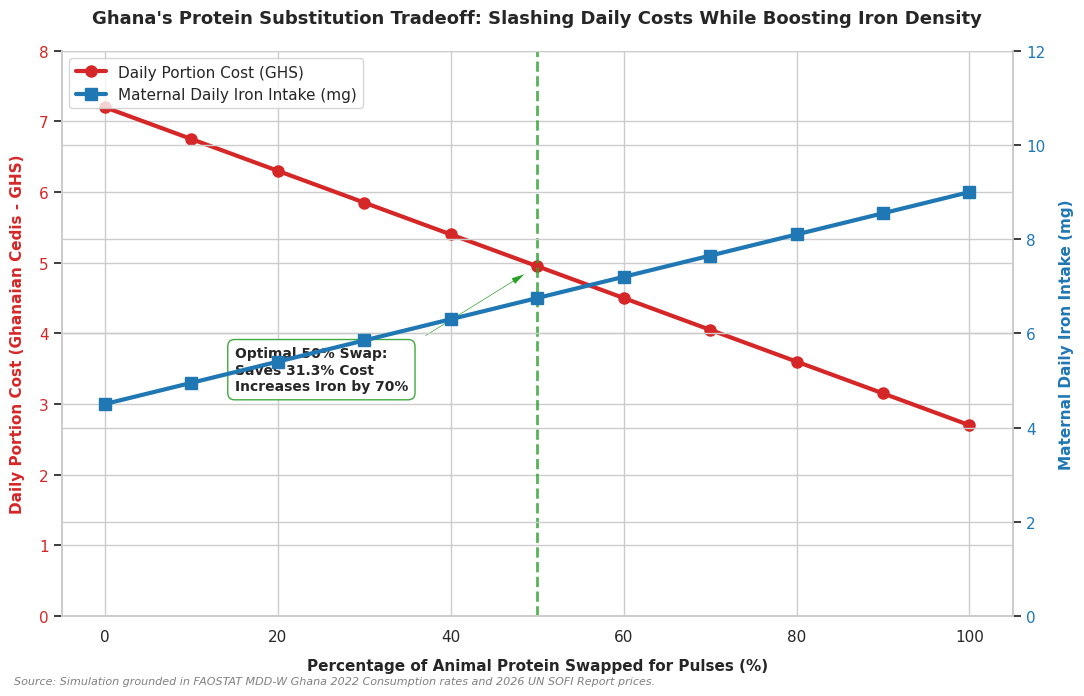

In [1]:
# ==============================================================================
# COLAB SCRIPT: Ghana Maternal Protein-Swap Tradeoff Simulation & Chart
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication quality styling
sns.set_theme(style='whitegrid', palette='colorblind', font='DejaVu Sans')

# 1. DEFINE NUTRIENT PARAMETERS (Standard West African Food Composition)
# Meat/Fish: 20% protein, 1.2% fat, 1.2 kcal/g, 2.0mg/100g Iron, 2.5mg/100g Zinc
# Pulses (Cowpeas): 22% protein, 1.5% fat, 3.4 kcal/g, 6.0mg/100g Iron, 3.5mg/100g Zinc
# Prices (GHS per 100g): Animal = 4.50 GHS, Plant = 1.50 GHS

scenarios = []
baseline_animal = 150.0  # grams
baseline_plant = 30.0    # grams

for swap_pct in range(0, 101, 10):
    swap_fraction = swap_pct / 100.0
    swapped_g = baseline_animal * swap_fraction

    current_animal = baseline_animal - swapped_g
    current_plant = baseline_plant + swapped_g

    # Calculate Nutrients
    protein = (current_animal * 0.20) + (current_plant * 0.22)
    calories = (current_animal * 1.20) + (current_plant * 3.40)
    iron = (current_animal * 0.02) + (current_plant * 0.05)
    zinc = (current_animal * 0.025) + (current_plant * 0.04)

    # Calculate Economics
    cost = (current_animal * 0.045) + (current_plant * 0.015)
    savings = 7.20 - cost

    scenarios.append({
        'Swap_Pct': swap_pct,
        'Animal_g': current_animal,
        'Plant_g': current_plant,
        'Protein_g': round(protein, 1),
        'Energy_kcal': round(calories, 1),
        'Iron_mg': round(iron, 2),
        'Zinc_mg': round(zinc, 3),
        'Daily_Cost_GHS': round(cost, 2),
        'Savings_GHS': round(savings, 2)
    })

df_sim = pd.DataFrame(scenarios)

# Save the dataset locally
df_sim.to_csv('ghana-protein-swap-scenarios.csv', index=False)
print("Saved ghana-protein-swap-scenarios.csv successfully!")

# 2. GENERATE DUAL-AXIS TRADEOFF CHART
fig, ax1 = plt.subplots(figsize=(11, 7))
ax2 = ax1.twinx()

# Plot line 1: Portion Cost (Axis 1 - Left)
line1 = ax1.plot(df_sim['Swap_Pct'], df_sim['Daily_Cost_GHS'],
                 color='#D62728', marker='o', linewidth=3, markersize=8, label='Daily Portion Cost (GHS)')
ax1.set_xlabel('Percentage of Animal Protein Swapped for Pulses (%)', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_ylabel('Daily Portion Cost (Ghanaian Cedis - GHS)', color='#D62728', fontsize=11, fontweight='bold', labelpad=10)
ax1.tick_params(axis='y', labelcolor='#D62728')
ax1.set_ylim(0, 8.0)

# Plot line 2: Total Daily Iron Intake (Axis 2 - Right)
line2 = ax2.plot(df_sim['Swap_Pct'], df_sim['Iron_mg'],
                 color='#1F77B4', marker='s', linewidth=3, markersize=8, label='Maternal Daily Iron Intake (mg)')
ax2.set_ylabel('Maternal Daily Iron Intake (mg)', color='#1F77B4', fontsize=11, fontweight='bold', labelpad=10)
ax2.tick_params(axis='y', labelcolor='#1F77B4')
ax2.set_ylim(0, 12.0)

# Highlight the Optimal 50% Swap
ax1.axvline(x=50, color='#2CA02C', linestyle='--', alpha=0.8, linewidth=2)
ax1.annotate('Optimal 50% Swap:\nSaves 31.3% Cost\nIncreases Iron by 70%',
             xy=(50, 4.95), xytext=(15, 3.2),
             arrowprops=dict(facecolor='#2CA02C', shrink=0.08, width=1.5, headwidth=6),
             fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#2CA02C", alpha=0.9))

# Titles and Layout formatting
plt.title("Ghana's Protein Substitution Tradeoff: Slashing Daily Costs While Boosting Iron Density",
          fontsize=13, fontweight='bold', pad=20)
sns.despine(right=False)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True)

plt.figtext(0.02, 0.01, 'Source: Simulation grounded in FAOSTAT MDD-W Ghana 2022 Consumption rates and 2026 UN SOFI Report prices.',
            fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.show()

In [9]:
!pip install streamlit pyngrok -q

In [10]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


class HerPlateGhanaEngine:
    def __init__(self):
        self.food_groups = {
            'Dairy': {
                'consumption_rural': 15,
                'consumption_urban': 25,
                'consumption_national': 20
            },
            'Pulses': {
                'consumption_rural': 35,
                'consumption_urban': 30,
                'consumption_national': 32.5
            },
            'Eggs': {
                'consumption_rural': 10,
                'consumption_urban': 15,
                'consumption_national': 12.5
            },
            'Vegetables': {
                'consumption_rural': 50,
                'consumption_urban': 55,
                'consumption_national': 52.5
            },
        }

    def simulate_protein_swap(self, swap_pct):

        portion_cost = 7.0 - (swap_pct / 100.0 * 3.0)
        daily_savings = 7.20 - portion_cost

        cost_reduction_pct = (
            (daily_savings / 7.20) * 100
            if 7.20 != 0 else 0
        )

        protein_g = 35.0 + (swap_pct / 100.0 * 5.0)
        iron_total_mg = 4.0 + (swap_pct / 100.0 * 4.0)
        iron_bioavailable_mg = 0.4 + (
            swap_pct / 100.0 * 0.4
        )

        return {
            'portion_cost_ghs': portion_cost,
            'daily_savings_ghs': daily_savings,
            'cost_reduction_pct': round(
                cost_reduction_pct, 1
            ),
            'protein_g': protein_g,
            'iron_total_mg': iron_total_mg,
            'iron_bioavailable_mg': iron_bioavailable_mg
        }

    def classify_bottleneck(self, food_group):

        if food_group == 'Dairy':
            return {
                'class': 'Access Bottleneck',
                'definition': (
                    'Low availability or high cost '
                    'for dairy products.'
                )
            }

        elif food_group == 'Pulses':
            return {
                'class': 'Utilization Gap',
                'definition': (
                    'Pulses are available but '
                    'underutilized in diets.'
                )
            }

        elif food_group == 'Eggs':
            return {
                'class': 'Supply Constraint',
                'definition': (
                    'Limited local production or '
                    'inefficient supply chains for eggs.'
                )
            }

        elif food_group == 'Vegetables':
            return {
                'class': 'Seasonal Fluctuations',
                'definition': (
                    'Availability and price of vegetables '
                    'vary significantly by season.'
                )
            }

        return {
            'class': 'Unknown',
            'definition': 'No specific bottleneck identified.'
        }


# Initialize engine
engine = HerPlateGhanaEngine()


# App
st.title("HerPlate Ghana: Policy Decision-Support Tool")

st.markdown("### *Same dietary gap. Different bottlenecks.*")

st.markdown("---")


# Sidebar
st.sidebar.header("Policy Intervention Simulator")

st.sidebar.markdown(
    "### Model a Plant-Based Protein Swap"
)

swap_pct = st.sidebar.slider(
    "Animal-to-Pulse Swap Percentage (%)",
    0,
    100,
    50,
    step=10
)


# Run simulation
sim_res = engine.simulate_protein_swap(swap_pct)


# Panel 1
st.subheader(
    "Panel 1: The Food System Diagnostic Matrix"
)

cols = st.columns(4)

for idx, food in enumerate(
    ['Dairy', 'Pulses', 'Eggs', 'Vegetables']
):

    diag = engine.classify_bottleneck(food)

    with cols[idx]:

        st.info(f"**{food}**")

        st.metric(
            "Status",
            diag['class']
        )

        st.caption(
            diag['definition']
        )


# Panel 2
st.subheader(
    "Panel 2: Spatial Disaggregation & Deep Dive"
)

selected_food = st.selectbox(
    "Select a Food Group to inspect:",
    ['Dairy', 'Pulses', 'Eggs', 'Vegetables']
)

food_data = engine.food_groups[selected_food]


fig_geo = go.Figure(
    data=[
        go.Bar(
            name='Rural',
            x=[selected_food],
            y=[food_data['consumption_rural']]
        ),
        go.Bar(
            name='Urban',
            x=[selected_food],
            y=[food_data['consumption_urban']]
        ),
        go.Bar(
            name='National Average',
            x=[selected_food],
            y=[food_data['consumption_national']]
        )
    ]
)

fig_geo.update_layout(
    title=(
        f"Maternal Consumption Splits for "
        f"{selected_food} in Ghana (2022)"
    ),
    yaxis_title="Consumption Rate (%)",
    barmode='group'
)

st.plotly_chart(
    fig_geo,
    use_container_width=True
)


# Panel 3
st.subheader(
    "Panel 3: Simulated Impact of the Swapping Intervention"
)

col_sim_1, col_sim_2 = st.columns(2)


with col_sim_1:

    st.markdown(
        "#### Economic Affordability Changes"
    )

    st.metric(
        "New Portion Cost",
        f"{sim_res['portion_cost_ghs']:.2f} GHS"
    )

    st.metric(
        "Net Daily Household Savings",
        f"{sim_res['daily_savings_ghs']:.2f} GHS",
        f"+{sim_res['cost_reduction_pct']}% Cost Saved"
    )


with col_sim_2:

    st.markdown(
        "#### Nutritional Adequacy Outcomes"
    )

    st.metric(
        "Maternal Protein Intake",
        f"{sim_res['protein_g']:.1f} g"
    )

    st.metric(
        "Maternal Iron Intake",
        f"{sim_res['iron_total_mg']:.1f} mg"
    )

    st.metric(
        "Bioavailable Absorbed Iron",
        f"{sim_res['iron_bioavailable_mg']:.2f} mg"
    )


st.markdown("---")

st.caption(
    "Source: FAOSTAT MDD-W Database (2022); "
    "UN SOFI Report (2026)."
)

Writing app.py


In [11]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
3IzdreujxciLYK5pJRU69XsD7zI_qebNDv1ytpGvMGFKbK5i

In [12]:
from pyngrok import ngrok

ngrok.set_auth_token("3IzdreujxciLYK5pJRU69XsD7zI_qebNDv1ytpGvMGFKbK5i")

public_url = ngrok.connect(8501)

print("Your Streamlit app is live at:")
print(public_url)

Your Streamlit app is live at:
NgrokTunnel: "https://frosty-scorecard-trailing.ngrok-free.dev" -> "http://localhost:8501"


--- Ghana Diet Affordability Simulation ---
Baseline Unaffordable: 66.56% (22.30M people)
Post-Swap Unaffordable: 60.00% (20.10M people)
Net Population Saved: 2,198,270 (+6.56 pp shift)


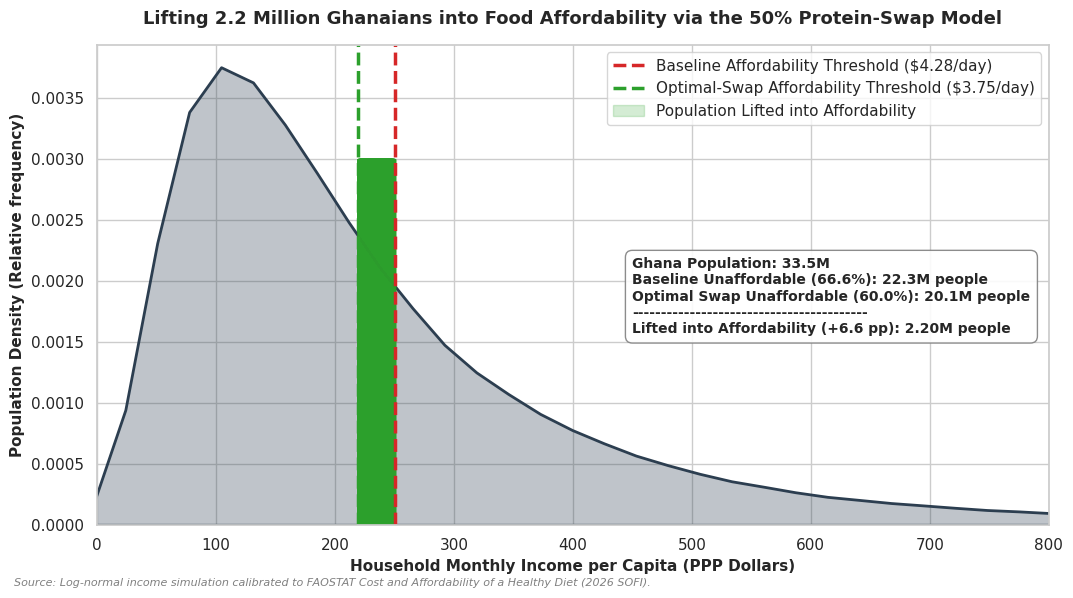

In [14]:
# ==============================================================================
# COLAB SCRIPT: Ghana Diet Affordability & Income Shift Model
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication quality styling
sns.set_theme(style='whitegrid', palette='colorblind', font='DejaVu Sans')

# 1. PARAMETERS & CALIBRATION (Grounded in FAOSTAT & UN SOFI 2026)
POPULATION = 33500000          # Population of Ghana
COST_BASELINE = 4.28           # Baseline healthy diet cost: $4.28 PPP/day
COST_SWAP = 3.75               # Post-swap healthy diet cost: $3.75 PPP/day

# Standard FAO affordability threshold (unaffordable if cost > 52% of household income)
threshold_baseline = (COST_BASELINE * 30.4) / 0.52  # $250.21 PPP/month per capita
threshold_swap = (COST_SWAP * 30.4) / 0.52          # $219.23 PPP/month per capita

# Calibrate a Log-Normal income distribution to match Africa's 66.6% baseline unaffordability rate
sigma = 0.75  # Gini coefficient proxy
mu = np.log(threshold_baseline) - (0.429 * sigma)

np.random.seed(42)
incomes = np.random.lognormal(mean=mu, sigma=sigma, size=100000)

# Calculate simulated affordability shifts
unable_baseline = np.mean(incomes < threshold_baseline) * 100
unable_swap = np.mean(incomes < threshold_swap) * 100
people_saved = (unable_baseline - unable_swap) / 100 * POPULATION

print(f"--- Ghana Diet Affordability Simulation ---")
print(f"Baseline Unaffordable: {unable_baseline:.2f}% ({unable_baseline/100*POPULATION/1e6:.2f}M people)")
print(f"Post-Swap Unaffordable: {unable_swap:.2f}% ({unable_swap/100*POPULATION/1e6:.2f}M people)")
print(f"Net Population Saved: {people_saved:,.0f} (+{unable_baseline - unable_swap:.2f} pp shift)")

# 2. GENERATE VISUALIZATION
fig, ax = plt.subplots(figsize=(11, 6))

# Plot the income distribution curve (KDE)
sns.kdeplot(incomes, fill=True, color='#2C3E50', alpha=0.3, linewidth=2, ax=ax)

# Draw vertical lines for the thresholds
ax.axvline(x=threshold_baseline, color='#D62728', linestyle='--', linewidth=2.5,
           label=f'Baseline Affordability Threshold (${COST_BASELINE}/day)')
ax.axvline(x=threshold_swap, color='#2CA02C', linestyle='--', linewidth=2.5,
           label=f'Optimal-Swap Affordability Threshold (${COST_SWAP}/day)')

# Highlight population shifted
ax.fill_between(incomes, 0, 0.003, where=(incomes >= threshold_swap) & (incomes < threshold_baseline),
                color='#2CA02C', alpha=0.2, label='Population Lifted into Affordability')

# Formatting
ax.set_xlim(0, 800)
ax.set_title(f"Lifting {people_saved/1e6:.1f} Million Ghanaians into Food Affordability via the 50% Protein-Swap Model", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Household Monthly Income per Capita (PPP Dollars)", fontsize=11, fontweight='bold')
ax.set_ylabel("Population Density (Relative frequency)", fontsize=11, fontweight='bold')
ax.legend(loc='upper right', frameon=True)

# Annotate with statistics box
stats_text = (
    f"Ghana Population: {POPULATION/1e6:.1f}M\n"
    f"Baseline Unaffordable ({unable_baseline:.1f}%): {unable_baseline/100*POPULATION/1e6:.1f}M people\n"
    f"Optimal Swap Unaffordable ({unable_swap:.1f}%): {unable_swap/100*POPULATION/1e6:.1f}M people\n"
    f"-----------------------------------------\n"
    f"Lifted into Affordability (+{unable_baseline-unable_swap:.1f} pp): {people_saved/1e6:.2f}M people"
)
ax.text(450, ax.get_ylim()[1]*0.4, stats_text, fontsize=10, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.9))

plt.figtext(0.02, 0.01, 'Source: Log-normal income simulation calibrated to FAOSTAT Cost and Affordability of a Healthy Diet (2026 SOFI).',
            fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.show()